# Baseline Strategies

Five baselines to set the bar before building the regime model.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_config
from src.allocation import (
    get_monthly_signal_dates,
    buy_and_hold,
    equal_weight,
    static_allocation,
    momentum_rotation,
    inverse_volatility,
)
from src.backtest import run_backtest
from src.metrics import compare_strategies

config = load_config(ROOT / "config" / "settings.json")
cash_rate = config["cash_proxy"]["annual_rate_pct"] / 100
cost_bps  = config["backtest"]["cost_scenarios_bps"]["base"]

print(f"Cash rate: {cash_rate:.2%} annual")
print(f"Base cost: {cost_bps} bps per rebalance")


Cash rate: 1.50% annual
Base cost: 20 bps per rebalance


## 1. Load data


In [2]:
prices = pd.read_parquet(ROOT / "data" / "processed" / "adj_close.parquet")
tickers = prices.columns.tolist()
labels = {t: info["label"] for t, info in config["etf_universe"].items()}

print(f"Loaded: {prices.shape[0]} trading days, {len(tickers)} ETFs")
print(f"Period: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Tickers: {tickers}")


Loaded: 2146 trading days, 4 ETFs
Period: 2017-09-19 to 2026-07-21
Tickers: ['0050.TW', '00713.TW', '00679B.TWO', '00635U.TW']


## 2. Signal dates

Signal = last trading day of each month. Execution = next trading day (inside backtest engine).
First 12 months skipped for momentum lookback warmup.


In [3]:
signal_dates = get_monthly_signal_dates(prices)

# Skip the first 12 months for warmup (momentum needs lookback)
warmup_months = 12
signal_dates = signal_dates[warmup_months:]

print(f"Total signal dates: {len(signal_dates)}")
print(f"First signal: {signal_dates[0].date()}")
print(f"Last signal:  {signal_dates[-1].date()}")


Total signal dates: 95
First signal: 2018-09-28
Last signal:  2026-07-21


## 3. Define strategies


In [4]:
core_ticker = "0050.TW"

strategies = {}

# 1. Buy-and-hold: 100% core equity
strategies["Buy & Hold 0050"] = buy_and_hold(signal_dates, tickers, core_ticker)

# 2. Equal weight: 25% each, monthly rebalanced
strategies["Equal Weight"] = equal_weight(signal_dates, tickers)

# 3. Static 50/20/20/10: a simple multi-asset benchmark
strategies["Static 50/20/20/10"] = static_allocation(
    signal_dates, tickers,
    weight_map={
        "0050.TW":    0.50,
        "00713.TW":   0.20,
        "00679B.TWO": 0.20,
        "00635U.TW":  0.10,
    },
)

# 4. Momentum rotation: top 2 by 6-month return
strategies["Momentum Top-2"] = momentum_rotation(
    prices, signal_dates, lookback_days=126, top_n=2,
)

# 5. Inverse volatility: weight by 1/vol(60d)
strategies["Inverse Vol"] = inverse_volatility(
    prices, signal_dates, lookback_days=60,
)

# Quick sanity check: all weight rows sum to <= 1
for name, w in strategies.items():
    row_sums = w.sum(axis=1)
    assert (row_sums <= 1.0 + 1e-9).all(), f"{name}: weights exceed 1.0"
    print(f"{name:25s}  mean weights: {w.mean().round(3).to_dict()}")


Buy & Hold 0050            mean weights: {'0050.TW': 1.0, '00713.TW': 0.0, '00679B.TWO': 0.0, '00635U.TW': 0.0}
Equal Weight               mean weights: {'0050.TW': 0.25, '00713.TW': 0.25, '00679B.TWO': 0.25, '00635U.TW': 0.25}
Static 50/20/20/10         mean weights: {'0050.TW': 0.5, '00713.TW': 0.2, '00679B.TWO': 0.2, '00635U.TW': 0.1}
Momentum Top-2             mean weights: {'0050.TW': 0.337, '00713.TW': 0.289, '00679B.TWO': 0.132, '00635U.TW': 0.242}
Inverse Vol                mean weights: {'0050.TW': 0.18, '00713.TW': 0.321, '00679B.TWO': 0.269, '00635U.TW': 0.23}


## 4. Run backtests


In [5]:
results = []
for name, weights in strategies.items():
    res = run_backtest(
        prices=prices,
        target_weights=weights,
        cost_bps=cost_bps,
        cash_rate_annual=cash_rate,
        name=name,
    )
    results.append(res)
    print(f"{name:25s}  days={len(res.daily_returns):5d}  "
          f"final={res.cumulative.iloc[-1]:.3f}  "
          f"turnover/yr={res.turnover.sum() / (len(res.daily_returns)/252):.2f}")


Buy & Hold 0050            days= 1894  final=6.006  turnover/yr=0.00
Equal Weight               days= 1894  final=2.745  turnover/yr=0.37
Static 50/20/20/10         days= 1894  final=3.552  turnover/yr=0.34
Momentum Top-2             days= 1894  final=3.403  turnover/yr=4.05
Inverse Vol                days= 1894  final=2.598  turnover/yr=1.31


## 5. Comparison table


In [6]:
comparison = compare_strategies(results, risk_free_annual=cash_rate)
comparison


,Annual Return,Annual Volatility,Sharpe,Sortino,Max Drawdown,Max DD Duration,Calmar,Monthly Win Rate,Worst Month,Best Month,Annual Turnover,Total Cost
Buy & Hold 0050,0.2694,0.2160,1.144,1.206,-0.3383,499.0,0.796,0.628,-0.1410,0.2509,0.000,0.0000
Equal Weight,0.1438,0.1062,1.178,1.163,-0.2075,430.0,0.693,0.638,-0.0702,0.0832,0.368,0.0055
Static 50/20/20/10,0.1837,0.1334,1.219,1.230,-0.2562,462.0,0.717,0.670,-0.0849,0.1281,0.343,0.0052
Momentum Top-2,0.1770,0.1548,1.034,0.978,-0.2397,531.0,0.738,0.596,-0.1158,0.1619,4.050,0.0609
Inverse Vol,0.1355,0.0975,1.199,1.176,-0.1964,312.0,0.690,0.691,-0.0603,0.0749,1.306,0.0196


## 6. Cumulative return


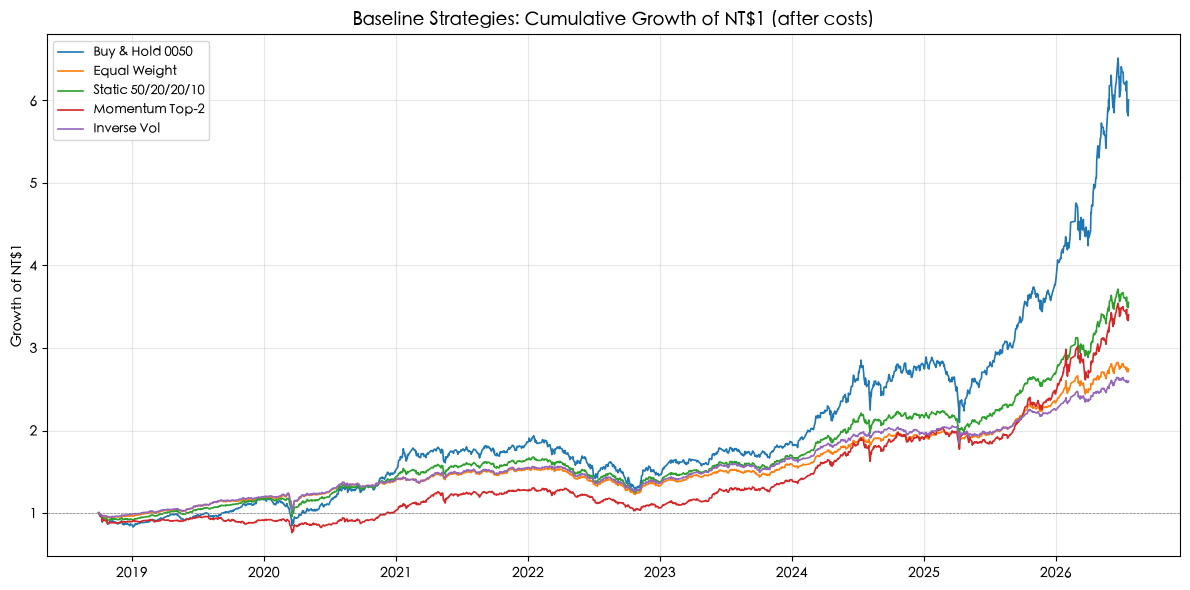

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/baselines_cumulative.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
for res in results:
    ax.plot(res.cumulative.index, res.cumulative.values, label=res.name, linewidth=1.2)

ax.set_title("Baseline Strategies: Cumulative Growth of NT$1 (after costs)", fontsize=13)
ax.set_ylabel("Growth of NT$1")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.5)
plt.tight_layout()

fig_path = ROOT / "figures" / "baselines_cumulative.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## 7. Drawdown


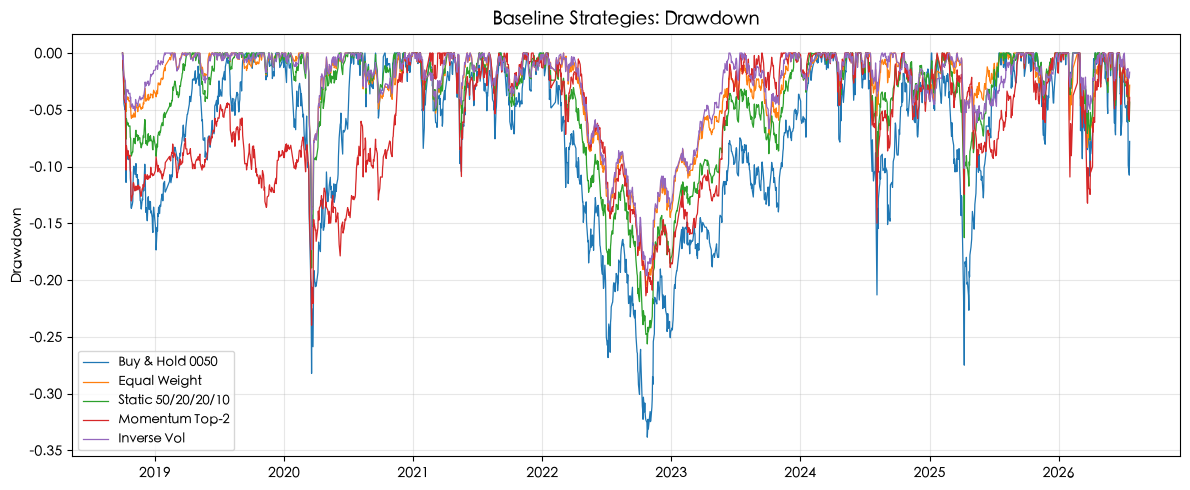

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/baselines_drawdown.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for res in results:
    cum = res.cumulative
    dd = cum / cum.cummax() - 1
    ax.plot(dd.index, dd.values, label=res.name, linewidth=0.9)

ax.set_title("Baseline Strategies: Drawdown", fontsize=13)
ax.set_ylabel("Drawdown")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = ROOT / "figures" / "baselines_drawdown.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## 8. Momentum weight history


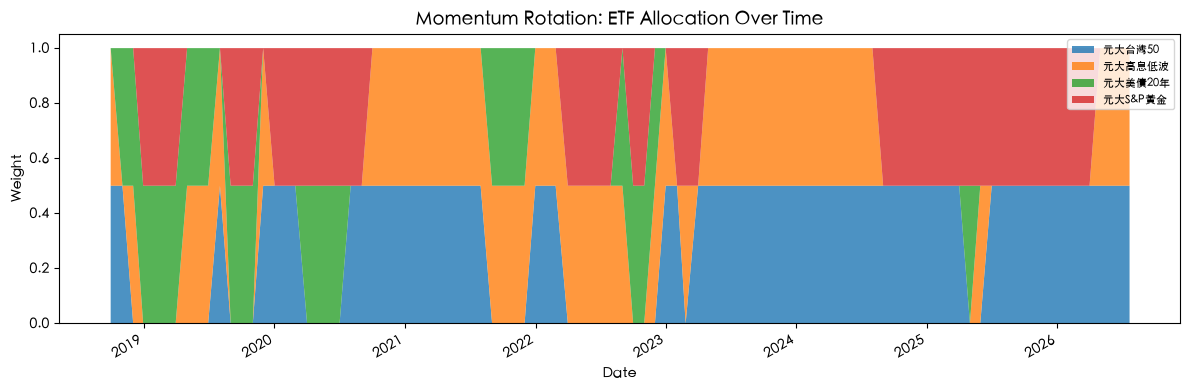

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/momentum_weights.png


In [9]:
mom_weights = strategies["Momentum Top-2"]
mom_labels = mom_weights.rename(columns=labels)

fig, ax = plt.subplots(figsize=(12, 4))
mom_labels.plot.area(ax=ax, linewidth=0, alpha=0.8)
ax.set_title("Momentum Rotation: ETF Allocation Over Time", fontsize=13)
ax.set_ylabel("Weight")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()

fig_path = ROOT / "figures" / "momentum_weights.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## 9. Cost sensitivity


In [10]:
cost_scenarios = config["backtest"]["cost_scenarios_bps"]
cost_tables = {}

for scenario_name, bps in cost_scenarios.items():
    scenario_results = []
    for name, weights in strategies.items():
        res = run_backtest(
            prices=prices,
            target_weights=weights,
            cost_bps=bps,
            cash_rate_annual=cash_rate,
            name=name,
        )
        scenario_results.append(res)
    tbl = compare_strategies(scenario_results, risk_free_annual=cash_rate)
    cost_tables[scenario_name] = tbl[["Sharpe", "Max Drawdown", "Annual Turnover"]]

print("=== Sharpe Ratio by Cost Scenario ===")
sharpe_compare = pd.DataFrame({
    k: v["Sharpe"] for k, v in cost_tables.items()
})
print(sharpe_compare.to_string())


=== Sharpe Ratio by Cost Scenario ===
                      low   base  conservative
Buy & Hold 0050     1.144  1.144         1.144
Equal Weight        1.181  1.178         1.171
Static 50/20/20/10  1.221  1.219         1.214
Momentum Top-2      1.060  1.034         0.980
Inverse Vol         1.212  1.199         1.172


## Notes

- Static 50/20/20/10 is the strongest baseline by Sharpe and Sortino.
- Momentum Top-2 has the highest turnover (~4x/year) and is most cost-sensitive.
- The regime strategy must beat Static and Inverse Vol, not just Buy & Hold.
